In [233]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

from __future__ import annotations
import argparse

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score, recall_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import ks_2samp # => Kiểm tra numerical distribution
from sklearn.compose import ColumnTransformer
from sklearn.base import clone
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [234]:
df_test = pd.read_parquet("/kaggle/input/datasets/dhoogla/unswnb15/UNSW_NB15_testing-set.parquet")
df_train = pd.read_parquet("/kaggle/input/datasets/dhoogla/unswnb15/UNSW_NB15_training-set.parquet")
full_df = pd.concat([df_train, df_test], ignore_index=True)

In [235]:
df_test.sample(5)

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
16148,0.000009,udp,dns,INT,2,0,114,0,111111.109375,5.066666e+07,...,0,0,15,10,0,0,0,0,Generic,1
56145,0.000001,rsvp,-,INT,2,0,200,0,1000000.000000,8.000000e+08,...,0,0,6,6,0,0,0,0,Analysis,1
49313,0.000008,udp,dns,INT,2,0,114,0,125000.000000,5.700000e+07,...,0,0,7,4,0,0,0,0,Generic,1
79759,0.000000,arp,-,INT,1,0,46,0,0.000000,0.000000e+00,...,0,0,1,1,0,0,0,1,Normal,0
46822,0.889593,tcp,pop3,FIN,24,52,1152,48212,84.308220,9.928136e+03,...,0,0,1,1,0,0,0,0,Exploits,1


In [236]:
df_train.sample(5)

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
55772,0.541184,tcp,ftp-data,FIN,8,8,364,1736,27.717005,4.715586e+03,...,0,0,1,1,0,0,0,0,Exploits,1
104036,0.000010,ipcv,-,INT,2,0,200,0,100000.000000,8.000000e+07,...,0,0,3,3,0,0,0,0,Exploits,1
80999,0.000008,trunk-1,-,INT,2,0,200,0,125000.000000,1.000000e+08,...,0,0,2,2,0,0,0,0,Exploits,1
36593,2.112225,tcp,-,FIN,182,196,14192,45832,178.484772,5.346021e+04,...,0,0,1,1,0,0,0,0,Normal,0
119958,0.000001,udp,dns,INT,2,0,114,0,1000000.000000,4.560000e+08,...,0,0,18,18,0,0,0,0,Generic,1


In [237]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82332 entries, 0 to 82331
Data columns (total 36 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   dur                82332 non-null  float32 
 1   proto              82332 non-null  category
 2   service            82332 non-null  category
 3   state              82332 non-null  category
 4   spkts              82332 non-null  int16   
 5   dpkts              82332 non-null  int16   
 6   sbytes             82332 non-null  int32   
 7   dbytes             82332 non-null  int32   
 8   rate               82332 non-null  float32 
 9   sload              82332 non-null  float32 
 10  dload              82332 non-null  float32 
 11  sloss              82332 non-null  int16   
 12  dloss              82332 non-null  int16   
 13  sinpkt             82332 non-null  float32 
 14  dinpkt             82332 non-null  float32 
 15  sjit               82332 non-null  float32 
 16  djit

In [238]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 36 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   dur                175341 non-null  float32 
 1   proto              175341 non-null  category
 2   service            175341 non-null  category
 3   state              175341 non-null  category
 4   spkts              175341 non-null  int16   
 5   dpkts              175341 non-null  int16   
 6   sbytes             175341 non-null  int32   
 7   dbytes             175341 non-null  int32   
 8   rate               175341 non-null  float32 
 9   sload              175341 non-null  float32 
 10  dload              175341 non-null  float32 
 11  sloss              175341 non-null  int16   
 12  dloss              175341 non-null  int16   
 13  sinpkt             175341 non-null  float32 
 14  dinpkt             175341 non-null  float32 
 15  sjit               175341 non-null

In [239]:
print(df_test.shape)
print(df_train.shape)

(82332, 36)
(175341, 36)


In [240]:
df_test.isnull().sum()

dur                  0
proto                0
service              0
state                0
spkts                0
dpkts                0
sbytes               0
dbytes               0
rate                 0
sload                0
dload                0
sloss                0
dloss                0
sinpkt               0
dinpkt               0
sjit                 0
djit                 0
swin                 0
stcpb                0
dtcpb                0
dwin                 0
tcprtt               0
synack               0
ackdat               0
smean                0
dmean                0
trans_depth          0
response_body_len    0
ct_src_dport_ltm     0
ct_dst_sport_ltm     0
is_ftp_login         0
ct_ftp_cmd           0
ct_flw_http_mthd     0
is_sm_ips_ports      0
attack_cat           0
label                0
dtype: int64

In [241]:
df_train.isnull().sum()

dur                  0
proto                0
service              0
state                0
spkts                0
dpkts                0
sbytes               0
dbytes               0
rate                 0
sload                0
dload                0
sloss                0
dloss                0
sinpkt               0
dinpkt               0
sjit                 0
djit                 0
swin                 0
stcpb                0
dtcpb                0
dwin                 0
tcprtt               0
synack               0
ackdat               0
smean                0
dmean                0
trans_depth          0
response_body_len    0
ct_src_dport_ltm     0
ct_dst_sport_ltm     0
is_ftp_login         0
ct_ftp_cmd           0
ct_flw_http_mthd     0
is_sm_ips_ports      0
attack_cat           0
label                0
dtype: int64

In [242]:
print(df_test.duplicated().sum())
print(df_train.duplicated().sum())

32361
78519


In [243]:
print(df_test.columns)
print(df_train.columns)

Index(['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt',
       'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt',
       'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
       'response_body_len', 'ct_src_dport_ltm', 'ct_dst_sport_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports',
       'attack_cat', 'label'],
      dtype='object')
Index(['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt',
       'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt',
       'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
       'response_body_len', 'ct_src_dport_ltm', 'ct_dst_sport_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports',
       'attack_cat', 'label'],
      dtype='object')


In [244]:
print(df_train['label'].value_counts())
print(df_test['label'].value_counts())

label
1    119341
0     56000
Name: count, dtype: int64
label
1    45332
0    37000
Name: count, dtype: int64


In [245]:
print(df_train['attack_cat'].value_counts())
print(df_test['attack_cat'].value_counts())

attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64
attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64


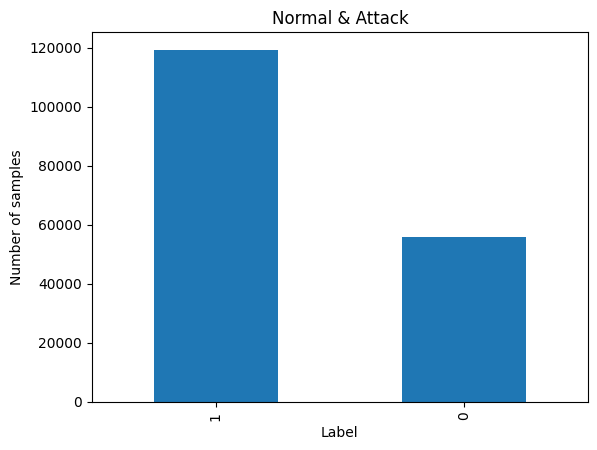

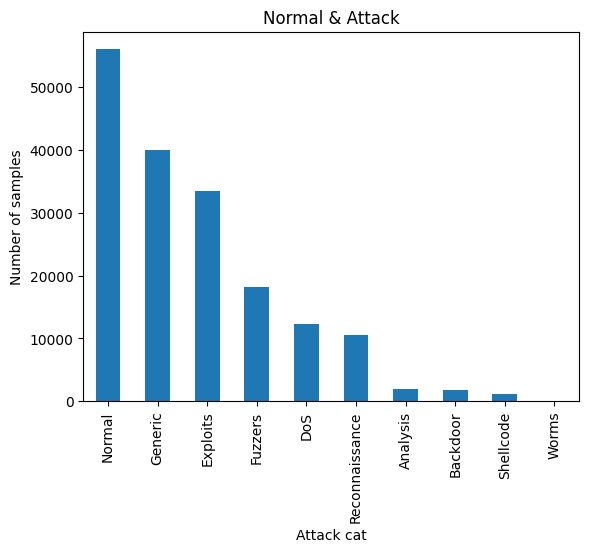

In [246]:
df_train["label"].value_counts().plot(kind="bar")
plt.title("Normal & Attack")
plt.xlabel("Label")
plt.ylabel("Number of samples")
plt.show()

df_train["attack_cat"].value_counts().plot(kind="bar")
plt.title("Normal & Attack")
plt.xlabel("Attack cat")
plt.ylabel("Number of samples")
plt.show()

In [247]:
# Phân loại các cột theo kiểu dữ liệu
categorical_cols = df_train.select_dtypes(
    include=["category", "object"]
).columns.tolist()
numeric_cols = df_train.select_dtypes(
    include=["number"]
).columns.tolist()
print("Các cột categorical:")
print(categorical_cols)
print("\nCác cột numeric:")
print(numeric_cols)

Các cột categorical:
['proto', 'service', 'state', 'attack_cat']

Các cột numeric:
['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports', 'label']


In [248]:
for col in categorical_cols:
    print({col})
    print("Số giá trị khác nhau:", df_train[col].nunique())
    print(df_train[col].value_counts().head(15))

{'proto'}
Số giá trị khác nhau: 133
proto
tcp       79946
udp       63283
unas      12084
arp        2859
ospf       2595
sctp       1150
any         300
gre         225
swipe       201
mobile      201
pim         201
sun-nd      201
ipv6        201
rsvp        200
sep         193
Name: count, dtype: int64
{'service'}
Số giá trị khác nhau: 13
service
-           94168
dns         47294
http        18724
smtp         5058
ftp-data     3995
ftp          3428
ssh          1302
pop3         1105
dhcp           94
snmp           80
ssl            56
irc            25
radius         12
Name: count, dtype: int64
{'state'}
Số giá trị khác nhau: 9
state
INT    82275
FIN    77825
CON    13152
REQ     1991
RST       83
ECO       12
PAR        1
URN        1
no         1
Name: count, dtype: int64
{'attack_cat'}
Số giá trị khác nhau: 10
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis 

In [249]:
# THống kê các numric features
numeric_features = [
    col for col in numeric_cols
    if col != "label"
]

df_train[numeric_features].describe().T
# .T => dùng để tạo bảng thay vì chỉ xuất hiện 1 dòng như describe

,count,mean,std,min,25%,50%,75%,max
dur,175341.0,1.359389e+00,6.483313e+00,0.0,0.000008,0.001582,6.680690e-01,5.999999e+01
spkts,175341.0,2.029866e+01,1.368876e+02,1.0,2.000000,2.000000,1.200000e+01,9.616000e+03
dpkts,175341.0,1.896959e+01,1.102583e+02,0.0,0.000000,2.000000,1.000000e+01,1.097400e+04
sbytes,175341.0,8.844844e+03,1.747656e+05,28.0,114.000000,430.000000,1.418000e+03,1.296523e+07
dbytes,175341.0,1.492892e+04,1.436542e+05,0.0,0.000000,164.000000,1.102000e+03,1.465555e+07
rate,175341.0,9.540618e+04,1.654177e+05,0.0,32.786140,3225.806641,1.250000e+05,1.000000e+06
sload,175341.0,7.345403e+07,1.883701e+08,0.0,13053.338867,879674.750000,8.888889e+07,5.988000e+09
dload,175341.0,6.712055e+05,2.423637e+06,0.0,0.000000,1447.022705,2.784487e+04,2.242273e+07
sloss,175341.0,4.953000e+00,6.600506e+01,0.0,0.000000,0.000000,3.000000e+00,4.803000e+03
dloss,175341.0,6.948010e+00,5.273300e+01,0.0,0.000000,0.000000,2.000000e+00,5.484000e+03


In [250]:
# So sánh các numerical feature giữa Normal và Attack

normal_stats = df_train[df_train["label"] == 0][numeric_features].mean()
attack_stats = df_train[df_train["label"] == 1][numeric_features].mean()

comparison = pd.DataFrame({
    "Normal_mean": normal_stats,
    "Attack_mean": attack_stats
})

comparison["Difference"] = (
    comparison["Attack_mean"] - comparison["Normal_mean"]
)

comparison.sort_values(
    by="Difference",
    key=lambda x: x.abs(),
    ascending=False
)

,Normal_mean,Attack_mean,Difference
stcpb,1.473765e+09,7.325100e+08,-7.412553e+08
dtcpb,1.463697e+09,7.366857e+08,-7.270117e+08
sload,2.317070e+07,9.704916e+07,7.387846e+07
dload,2.062949e+06,1.813877e+04,-2.044810e+06
rate,1.379931e+04,1.336997e+05,1.199004e+05
dbytes,3.104946e+04,7.364456e+03,-2.368501e+04
sbytes,4.105703e+03,1.106866e+04,6.962952e+03
sinpkt,2.847882e+03,1.122896e+02,-2.735593e+03
response_body_len,3.834699e+03,1.351079e+03,-2.483620e+03
sjit,5.440296e+03,4.758506e+03,-6.817900e+02


In [251]:
# So sánh median và tỷ lệ giá trị bằng 0
# giữa Normal và Attack

normal_df = df_train[df_train["label"] == 0]
attack_df = df_train[df_train["label"] == 1]

comparison_median = pd.DataFrame({
    "Normal_median": normal_df[numeric_features].median(),
    "Attack_median": attack_df[numeric_features].median(),

    "Normal_zero_%": (
        (normal_df[numeric_features] == 0).mean() * 100
    ),

    "Attack_zero_%": (
        (attack_df[numeric_features] == 0).mean() * 100
    )
})

comparison_median

,Normal_median,Attack_median,Normal_zero_%,Attack_zero_%
dur,3.860250e-02,9.000000e-06,4.696429,0.022624
spkts,1.200000e+01,2.000000e+00,0.000000,0.000000
dpkts,1.000000e+01,0.000000e+00,11.885714,65.045542
sbytes,1.470000e+03,2.000000e+02,0.000000,0.000000
dbytes,1.112000e+03,0.000000e+00,11.885714,65.045542
rate,1.382257e+03,1.111111e+05,4.698214,0.283222
sload,4.313277e+05,5.066666e+07,4.712500,0.283222
dload,3.361206e+05,0.000000e+00,11.900000,65.045542
sloss,3.000000e+00,0.000000e+00,30.169643,65.822308
dloss,2.000000e+00,0.000000e+00,31.905357,66.004139


In [252]:
# Phân tích categorical features theo label

for col in ["proto", "service", "state"]:
    print(f"=== {col} ===")
    
    table = pd.crosstab(
        df_train[col],
        df_train["label"],
        normalize="index"
    ) * 100
    
    table.columns = ["Normal_%", "Attack_%"]
    
    # print(table.sort_values("Normal_%", ascending=False).head(15))
    print(table.sort_values("Attack_%", ascending=False).head(15))

=== proto ===
             Normal_%  Attack_%
proto                          
3pc               0.0     100.0
a/n               0.0     100.0
aes-sp3-d         0.0     100.0
any               0.0     100.0
argus             0.0     100.0
aris              0.0     100.0
ax.25             0.0     100.0
bbn-rcc           0.0     100.0
bna               0.0     100.0
cbt               0.0     100.0
br-sat-mon        0.0     100.0
cftp              0.0     100.0
chaos             0.0     100.0
crtp              0.0     100.0
compaq-peer       0.0     100.0
=== service ===
           Normal_%    Attack_%
service                        
dhcp       0.000000  100.000000
ssl        0.000000  100.000000
irc        0.000000  100.000000
pop3       0.361991   99.638009
snmp       1.250000   98.750000
dns       15.843447   84.156553
radius    16.666667   83.333333
http      28.562273   71.437727
smtp      31.217873   68.782127
ftp       35.530922   64.469078
-         38.773256   61.226744
ftp-data  

In [253]:
# Kiểm tra số lượng mẫu và tỷ lệ Attack của từng categorical value

for col in ["proto", "service", "state"]:
    print(f"=== {col} ===")

    analysis = pd.crosstab(
        df_train[col],
        df_train["label"]
    )

    analysis.columns = ["Normal_count", "Attack_count"]
    analysis["Total"] = (
        analysis["Normal_count"] +
        analysis["Attack_count"]
    )

    analysis["Attack_%"] = (
        analysis["Attack_count"] /
        analysis["Total"] * 100
    )

    print(
        analysis
        .sort_values("Total", ascending=False)
        .head(15)
    )

=== proto ===
        Normal_count  Attack_count  Total    Attack_%
proto                                                
tcp            39121         40825  79946   51.065719
udp            13922         49361  63283   78.000411
unas               0         12084  12084  100.000000
arp             2859             0   2859    0.000000
ospf              64          2531   2595   97.533719
sctp               0          1150   1150  100.000000
any                0           300    300  100.000000
gre                0           225    225  100.000000
swipe              0           201    201  100.000000
mobile             0           201    201  100.000000
pim                0           201    201  100.000000
sun-nd             0           201    201  100.000000
ipv6               0           201    201  100.000000
rsvp               0           200    200  100.000000
sep                0           193    193  100.000000
=== service ===
          Normal_count  Attack_count  Total    Attac

In [254]:
# Kiểm tra category trong train và test

for col in ["proto", "service", "state"]:

    train_values = set(df_train[col].unique())
    test_values = set(df_test[col].unique())

    only_in_train = train_values - test_values
    only_in_test = test_values - train_values

    print(f"\n{'=' * 50}")
    print(f"=== {col} ===")

    print("Số category trong train:", len(train_values))
    print("Số category trong test :", len(test_values))

    print("Chỉ xuất hiện trong train:", only_in_train)
    print("Chỉ xuất hiện trong test :", only_in_test)


=== proto ===
Số category trong train: 133
Số category trong test : 131
Chỉ xuất hiện trong train: {'icmp', 'rtp'}
Chỉ xuất hiện trong test : set()

=== service ===
Số category trong train: 13
Số category trong test : 13
Chỉ xuất hiện trong train: set()
Chỉ xuất hiện trong test : set()

=== state ===
Số category trong train: 9
Số category trong test : 7
Chỉ xuất hiện trong train: {'URN', 'ECO', 'PAR', 'no'}
Chỉ xuất hiện trong test : {'CLO', 'ACC'}


In [255]:
# Tách feature (X) và target (y)
feature_cols = [
    col for col in df_train.columns
    if col not in ["attack_cat", "label"]
]

X_train = df_train[feature_cols]
y_train = df_train["label"]

X_test = df_test[feature_cols]
y_test = df_test["label"]

print("Số lượng feature:", len(feature_cols))

print("\nX_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nX_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nDanh sách feature:")
print(feature_cols)

Số lượng feature: 34

X_train: (175341, 34)
y_train: (175341,)

X_test: (82332, 34)
y_test: (82332,)

Danh sách feature:
['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports']


In [256]:
# Chuẩn hóa các cột có dạng chữ sang dạng số
# Biến các categorical feature (proto, service, state) thành các cột 0/1
# Cấu hình encoder để bỏ qua category chưa từng thấy trong Test
categorical_features = ["proto", "service", "state"]

encoder = OneHotEncoder(
    handle_unknown="ignore", # => Xử lí các biến không có trong train sẽ được encoder tránh crash và các cột encoded tương ứng = 0
    sparse_output=False
)

X_train_cat = encoder.fit_transform( # => Encoder học category từ TRAIN
    X_train[categorical_features]
)

X_test_cat = encoder.transform( # => Test chỉ biến đổi theo những gì encoder đã học
    X_test[categorical_features]
)

print("Kích thước categorical sau encoding:")
print("X_train_cat:", X_train_cat.shape)
print("X_test_cat:", X_test_cat.shape)

Kích thước categorical sau encoding:
X_train_cat: (175341, 155)
X_test_cat: (82332, 155)


In [257]:
# Kiểm tra NaN và Inf trong numerical features
# NaN đã kiểm tra trước đó nên hiện tại chỉ cần kiểm tra inf trong 2 tập train và test
X_train_num = X_train[numeric_features]
X_test_num = X_test[numeric_features]

print("NaN trong X_train:", X_train_num.isna().sum().sum())
print("NaN trong X_test :", X_test_num.isna().sum().sum())

print("Inf trong X_train:", np.isinf(X_train_num).sum().sum())
print("Inf trong X_test :", np.isinf(X_test_num).sum().sum())

NaN trong X_train: 0
NaN trong X_test : 0
Inf trong X_train: 0
Inf trong X_test : 0


In [258]:
# Ghép numerical + categorical features
X_train_num_array = X_train_num.to_numpy()
X_test_num_array = X_test_num.to_numpy()

X_train_processed = np.hstack([
    X_train_num_array,
    X_train_cat
])

X_test_processed = np.hstack([
    X_test_num_array,
    X_test_cat
])

print("X_train_processed:", X_train_processed.shape)
print("X_test_processed :", X_test_processed.shape)

print("\nKiểu dữ liệu:")
print(X_train_processed.dtype)

X_train_processed: (175341, 186)
X_test_processed : (82332, 186)

Kiểu dữ liệu:
float64


In [259]:
# Tạo model baseline
rf_model = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

# Huấn luyện trên TRAIN
rf_model.fit(X_train_processed, y_train)

print("Đã train xong Random Forest!")

Đã train xong Random Forest!


In [260]:
# Dự đoán trên tập TEST

y_pred = rf_model.predict(X_test_processed)

print("Đã dự đoán xong!")
print("Số lượng dự đoán:", len(y_pred))

Đã dự đoán xong!
Số lượng dự đoán: 82332


In [261]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Normal", "Attack"]
))

#         Normal  Attack
# Normal  27343    9657
# Attack  1279     44053

Accuracy : 0.8671719380070932
Precision: 0.8202010798733942
Recall   : 0.9717859348804376
F1-score : 0.8895821974515862

Confusion Matrix:
[[27343  9657]
 [ 1279 44053]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.96      0.74      0.83     37000
      Attack       0.82      0.97      0.89     45332

    accuracy                           0.87     82332
   macro avg       0.89      0.86      0.86     82332
weighted avg       0.88      0.87      0.86     82332



In [262]:
# Kiểm tra thử feature quan trọng nhất của Random Forest => Cách mà Random Forest sử dụng feature tương đối nhiều trong dự đoán
# Tạo tên cho 186 feature sau preprocessing
encoded_feature_names = encoder.get_feature_names_out(
    categorical_features
)

all_feature_names = (
    numeric_features +
    list(encoded_feature_names)
)

feature_importance = pd.DataFrame({
    "feature": all_feature_names,
    "importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

print(feature_importance.head(20))

              feature  importance
19             synack    0.082205
7               dload    0.074659
6               sload    0.057081
5                rate    0.056360
4              dbytes    0.048457
3              sbytes    0.047300
10             sinpkt    0.045308
20             ackdat    0.045215
11             dinpkt    0.043015
0                 dur    0.042764
21              smean    0.041292
12               sjit    0.038306
2               dpkts    0.037073
18             tcprtt    0.034882
13               djit    0.034347
180         state_INT    0.032177
22              dmean    0.031162
26   ct_dst_sport_ltm    0.023131
1               spkts    0.019917
8               sloss    0.018438


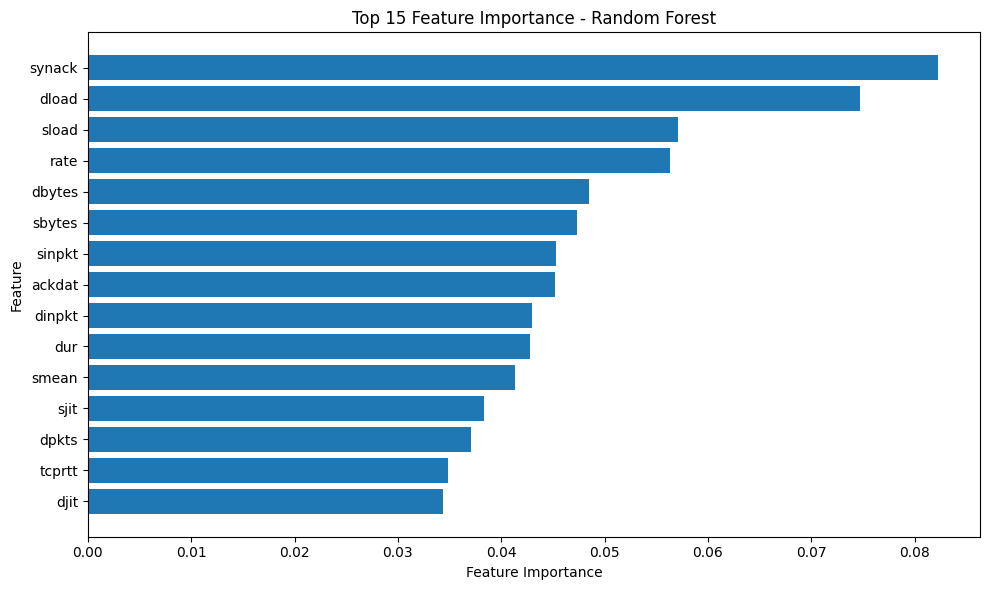

In [263]:
top_features = feature_importance.head(15).sort_values(
    by="importance"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importance - Random Forest")

plt.tight_layout()
plt.show()

In [264]:
# Xác định False Positive và False Negative
fp_mask = (y_test == 0) & (y_pred == 1)
fn_mask = (y_test == 1) & (y_pred == 0)

print("False Positive:", fp_mask.sum())
print("False Negative:", fn_mask.sum())

False Positive: 9657
False Negative: 1279


In [265]:
# So sánh các numerical features:
# Normal được dự đoán đúng (TN)
# với Normal bị dự đoán nhầm thành Attack (FP)
tn_mask = (y_test == 0) & (y_pred == 0)

tn_df = df_test.loc[tn_mask]
fp_df = df_test.loc[fp_mask]

comparison_fp = pd.DataFrame({
    "TN_mean": tn_df[numeric_features].mean(),
    "FP_mean": fp_df[numeric_features].mean(),

    "TN_median": tn_df[numeric_features].median(),
    "FP_median": fp_df[numeric_features].median()
})

comparison_fp

,TN_mean,FP_mean,TN_median,FP_median
dur,9.173530e-01,1.282772e+00,5.055600e-02,7.222280e-01
spkts,2.660184e+01,1.194719e+01,1.000000e+01,1.000000e+01
dpkts,3.192280e+01,6.989955e+00,8.000000e+00,8.000000e+00
sbytes,3.660371e+03,5.238938e+03,1.012000e+03,8.020000e+02
dbytes,2.501801e+04,8.299541e+02,5.260000e+02,3.540000e+02
rate,1.897229e+04,5.490216e+04,9.023050e+02,2.582025e+01
sload,2.140010e+07,9.171922e+07,3.269569e+05,1.002943e+04
dload,1.857351e+06,3.950665e+03,7.631496e+04,2.674353e+03
sloss,4.607468e+00,3.424045e+00,2.000000e+00,2.000000e+00
dloss,1.175219e+01,1.384799e+00,1.000000e+00,1.000000e+00


In [266]:
# So sánh tỉ lệ attack dự đoán và thực tế
print("Thực tế:")
print(y_test.value_counts())

print("\nModel dự đoán:")
print(pd.Series(y_pred).value_counts())

Thực tế:
label
1    45332
0    37000
Name: count, dtype: int64

Model dự đoán:
1    53710
0    28622
Name: count, dtype: int64


In [267]:
# Xác suất model dự đoán Attack
y_proba = rf_model.predict_proba(X_test_processed)[:, 1]

fp_probabilities = y_proba[fp_mask]

print("FP có xác suất Attack:")
print(pd.Series(fp_probabilities).describe())

FP có xác suất Attack:
count    9657.000000
mean        0.706135
std         0.131181
min         0.500905
25%         0.600000
50%         0.680000
75%         0.800000
max         1.000000
dtype: float64


In [268]:
# So sánh categorical features giữa TN và FP
categorical_compare = ["proto", "service", "state"]

for col in categorical_compare:
    print(f"=== {col} ===")

    tn_dist = tn_df[col].value_counts(normalize=True) * 100
    fp_dist = fp_df[col].value_counts(normalize=True) * 100

    comparison = pd.DataFrame({
        "TN_%": tn_dist,
        "FP_%": fp_dist
    }).fillna(0)

    comparison["Difference_%"] = (
        comparison["FP_%"] - comparison["TN_%"]
    )

    print(
        comparison.sort_values(
            "Difference_%",
            ascending=False
        ).head(15)
    )

=== proto ===
                  TN_%       FP_%  Difference_%
proto                                          
udp          20.886516  24.707466      3.820950
tcp          75.255093  75.292534      0.037441
3pc           0.000000   0.000000      0.000000
aes-sp3-d     0.000000   0.000000      0.000000
a/n           0.000000   0.000000      0.000000
any           0.000000   0.000000      0.000000
argus         0.000000   0.000000      0.000000
bna           0.000000   0.000000      0.000000
bbn-rcc       0.000000   0.000000      0.000000
aris          0.000000   0.000000      0.000000
ax.25         0.000000   0.000000      0.000000
cphb          0.000000   0.000000      0.000000
cftp          0.000000   0.000000      0.000000
chaos         0.000000   0.000000      0.000000
compaq-peer   0.000000   0.000000      0.000000
=== service ===
               TN_%       FP_%  Difference_%
service                                     
-         71.510076  80.998240      9.488164
http       9.124822

In [269]:
# So sánh phân phối numerical features:
# Normal trong TRAIN với Normal trong TEST
train_normal = df_train[df_train["label"] == 0]
test_normal = df_test[df_test["label"] == 0]

distribution_compare = pd.DataFrame({
    "Train_Normal_mean": train_normal[numeric_features].mean(),
    "Test_Normal_mean": test_normal[numeric_features].mean(),

    "Train_Normal_median": train_normal[numeric_features].median(),
    "Test_Normal_median": test_normal[numeric_features].median()
})

# Độ chênh lệch mean theo %
distribution_compare["Mean_Difference_%"] = (
    (distribution_compare["Test_Normal_mean"]
     - distribution_compare["Train_Normal_mean"])
    / distribution_compare["Train_Normal_mean"].replace(0, np.nan)
    * 100
)

print("So sánh phân phối Normal: TRAIN vs TEST")
print(
    distribution_compare
    .sort_values(
        "Mean_Difference_%",
        key=lambda x: x.abs(),
        ascending=False
    )
    .head(20)
)

# => Mục đích : xem những feature mà FP có giá trị cao có phải cũng đã thay đổi phân phối giữa Train Normal và Test Normal hay không.

So sánh phân phối Normal: TRAIN vs TEST
                   Train_Normal_mean  Test_Normal_mean  Train_Normal_median  \
synack                  1.732687e-02      4.101544e-02             0.000515   
tcprtt                  3.194473e-02      7.503419e-02             0.000645   
ackdat                  1.461787e-02      3.401875e-02             0.000125   
rate                    1.379931e+04      2.834999e+04          1382.256592   
sload                   2.317070e+07      3.975339e+07        431327.656250   
ct_flw_http_mthd        1.168929e-01      1.827838e-01             0.000000   
is_sm_ips_ports         4.932143e-02      2.475676e-02             0.000000   
sjit                    5.440296e+03      8.083228e+03            54.422672   
dinpkt                  1.211967e+02      1.754665e+02             0.910582   
sinpkt                  2.847882e+03      1.581859e+03             1.430907   
is_ftp_login            1.698214e-02      9.918919e-03             0.000000   
response_bod

In [270]:
# So sánh phân phối categorical features:
# Normal trong TRAIN với Normal trong TEST
for col in ["proto", "service", "state"]:

    print(f"=== {col} ===")

    train_dist = (
        train_normal[col]
        .value_counts(normalize=True) * 100
    )

    test_dist = (
        test_normal[col]
        .value_counts(normalize=True) * 100
    )

    comparison = pd.DataFrame({
        "Train_Normal_%": train_dist,
        "Test_Normal_%": test_dist
    }).fillna(0)

    comparison["Difference_%"] = (
        comparison["Test_Normal_%"]
        - comparison["Train_Normal_%"]
    )

    print(
        comparison
        .sort_values(
            "Difference_%",
            key=lambda x: x.abs(),
            ascending=False
        )
        .head(15)
    )

=== proto ===
             Train_Normal_%  Test_Normal_%  Difference_%
proto                                                   
tcp               69.858929      75.264865      5.405936
udp               24.860714      21.883784     -2.976931
arp                5.105357       2.667568     -2.437790
igmp               0.032143       0.081081      0.048938
icmp               0.026786       0.000000     -0.026786
ospf               0.114286       0.102703     -0.011583
rtp                0.001786       0.000000     -0.001786
argus              0.000000       0.000000      0.000000
a/n                0.000000       0.000000      0.000000
3pc                0.000000       0.000000      0.000000
any                0.000000       0.000000      0.000000
aes-sp3-d          0.000000       0.000000      0.000000
aris               0.000000       0.000000      0.000000
chaos              0.000000       0.000000      0.000000
compaq-peer        0.000000       0.000000      0.000000
=== service ===
 

In [271]:
# KS test:
# Kiểm tra Train Normal và Test Normal có khác phân phối hay không
ks_results = []

for col in numeric_features:

    train_values = train_normal[col].dropna()
    test_values = test_normal[col].dropna()

    statistic, p_value = ks_2samp(
        train_values,
        test_values
    )

    ks_results.append({
        "Feature": col,
        "KS_statistic": statistic,
        "p_value": p_value
    })

ks_df = pd.DataFrame(ks_results)

print("Các numerical features có khác biệt phân phối mạnh nhất:")

print(
    ks_df
    .sort_values("KS_statistic", ascending=False)
    .head(20)
)

Các numerical features có khác biệt phân phối mạnh nhất:
   Feature  KS_statistic        p_value
20  ackdat      0.238343   0.000000e+00
7    dload      0.234820   0.000000e+00
18  tcprtt      0.202311   0.000000e+00
22   dmean      0.201793   0.000000e+00
19  synack      0.201389   0.000000e+00
4   dbytes      0.177465   0.000000e+00
12    sjit      0.158959   0.000000e+00
9    dloss      0.156734   0.000000e+00
2    dpkts      0.151634   0.000000e+00
5     rate      0.145340   0.000000e+00
11  dinpkt      0.141609   0.000000e+00
10  sinpkt      0.139693   0.000000e+00
0      dur      0.133070   0.000000e+00
1    spkts      0.128710   0.000000e+00
3   sbytes      0.122401  2.294967e-291
6    sload      0.118207  1.046411e-271
8    sloss      0.117917  2.233890e-270
13    djit      0.093204  6.900185e-169
21   smean      0.069076   6.988113e-93
14    swin      0.054086   4.349774e-57


In [272]:
# Các feature có KS statistic cao nhất
top_features = (
    ks_df
    .sort_values("KS_statistic", ascending=False)
    .head(10)["Feature"]
    .tolist()
)

comparison = []

for col in top_features:

    train_values = train_normal[col].dropna()
    test_values = test_normal[col].dropna()

    comparison.append({
        "Feature": col,

        "Train_Mean": train_values.mean(),
        "Test_Mean": test_values.mean(),

        "Train_Median": train_values.median(),
        "Test_Median": test_values.median(),

        "Train_Q25": train_values.quantile(0.25),
        "Test_Q25": test_values.quantile(0.25),

        "Train_Q75": train_values.quantile(0.75),
        "Test_Q75": test_values.quantile(0.75),
    })

distribution_detail = pd.DataFrame(comparison)

print("Chi tiết các feature có KS statistic cao nhất:")
display(distribution_detail)

Chi tiết các feature có KS statistic cao nhất:


,Feature,Train_Mean,Test_Mean,Train_Median,Test_Median,Train_Q25,Test_Q25,Train_Q75,Test_Q75
0,ackdat,1.461787e-02,3.401875e-02,0.000125,0.000146,0.000000,0.000000,1.490000e-04,0.061318
1,dload,2.062949e+06,1.373614e+06,336120.625000,7679.021484,4790.794556,1822.659058,1.313494e+06,657433.062500
2,tcprtt,3.194473e-02,7.503419e-02,0.000645,0.000707,0.000000,0.000000,7.610000e-04,0.138034
3,dmean,2.530674e+02,1.735489e+02,89.000000,76.000000,53.000000,44.000000,4.820000e+02,125.000000
4,synack,1.732687e-02,4.101544e-02,0.000515,0.000554,0.000000,0.000000,6.080000e-04,0.072924
5,dbytes,3.104946e+04,1.870493e+04,1112.000000,354.000000,178.000000,164.000000,1.016800e+04,1890.000000
6,sjit,5.440296e+03,8.083228e+03,54.422672,638.198120,0.015678,0.000000,2.292889e+03,4271.991577
7,dloss,1.423693e+01,9.046297e+00,2.000000,1.000000,0.000000,0.000000,8.000000e+00,4.000000
8,dpkts,3.805770e+01,2.541532e+01,10.000000,8.000000,2.000000,2.000000,4.000000e+01,18.000000
9,rate,1.379931e+04,2.834999e+04,1382.256592,118.625534,30.730738,22.889781,3.177693e+03,3125.000000


In [273]:
# Tạo bản sao df_test để phân tích
df_test_analysis = df_test.copy()

# Đưa prediction vào DataFrame
df_test_analysis["prediction"] = y_pred

# False Positive:
# Thực tế Normal (label = 0)
# nhưng model dự đoán Attack (prediction = 1)

fp = df_test_analysis[
    (df_test_analysis["label"] == 0) &
    (df_test_analysis["prediction"] == 1)
]

# True Negative:
# Thực tế Normal
# và model dự đoán Normal

tn = df_test_analysis[
    (df_test_analysis["label"] == 0) &
    (df_test_analysis["prediction"] == 0)
]

print("Số TN:", len(tn))
print("Số FP:", len(fp))

Số TN: 27343
Số FP: 9657


In [274]:
# So sánh TN và FP trên các feature có KS statistic cao
top_features = (
    ks_df
    .sort_values("KS_statistic", ascending=False)
    .head(10)["Feature"]
    .tolist()
)

comparison_fp_tn = []

for col in top_features:

    tn_values = tn[col].dropna()
    fp_values = fp[col].dropna()

    comparison_fp_tn.append({
        "Feature": col,

        "TN_Median": tn_values.median(),
        "FP_Median": fp_values.median(),

        "TN_Q25": tn_values.quantile(0.25),
        "FP_Q25": fp_values.quantile(0.25),

        "TN_Q75": tn_values.quantile(0.75),
        "FP_Q75": fp_values.quantile(0.75)
    })

fp_tn_detail = pd.DataFrame(comparison_fp_tn)

display(fp_tn_detail)

,Feature,TN_Median,FP_Median,TN_Q25,FP_Q25,TN_Q75,FP_Q75
0,ackdat,0.000135,0.060524,0.000000,0.015261,0.001010,0.084928
1,dload,76314.960938,2674.352783,2605.094971,114.581734,899799.468750,4572.128418
2,tcprtt,0.000668,0.131516,0.000000,0.040197,0.002549,0.176915
3,dmean,82.000000,45.000000,44.000000,43.000000,180.000000,56.000000
4,synack,0.000527,0.067679,0.000000,0.015419,0.002139,0.092545
5,dbytes,526.000000,354.000000,164.000000,268.000000,8824.000000,682.000000
6,sjit,75.072838,3793.450195,0.000000,1114.666626,3108.964478,7122.522461
7,dloss,1.000000,1.000000,0.000000,0.000000,7.000000,2.000000
8,dpkts,8.000000,8.000000,2.000000,6.000000,24.000000,8.000000
9,rate,902.304993,25.820250,27.739200,15.905910,3149.959229,90.631943


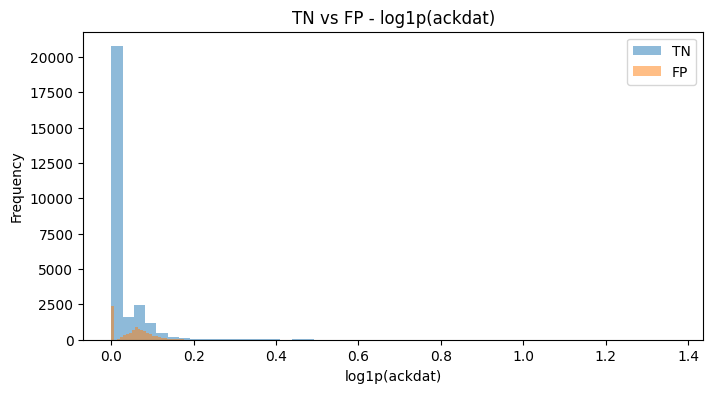

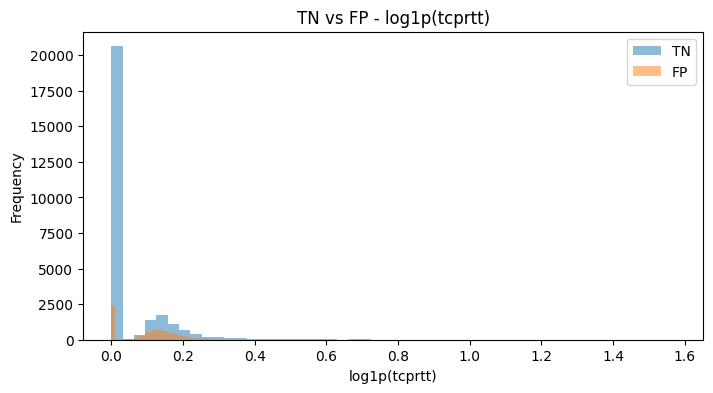

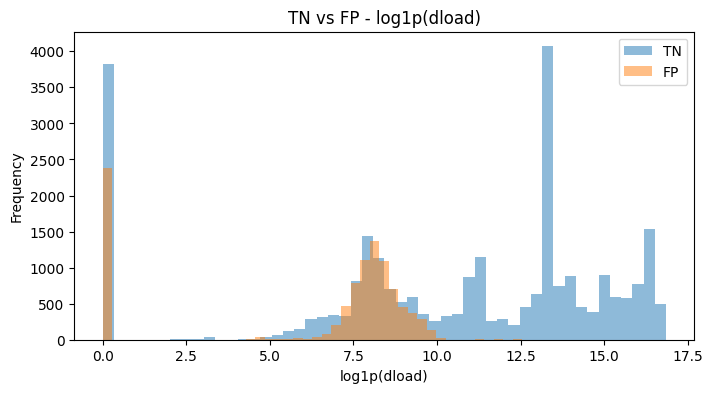

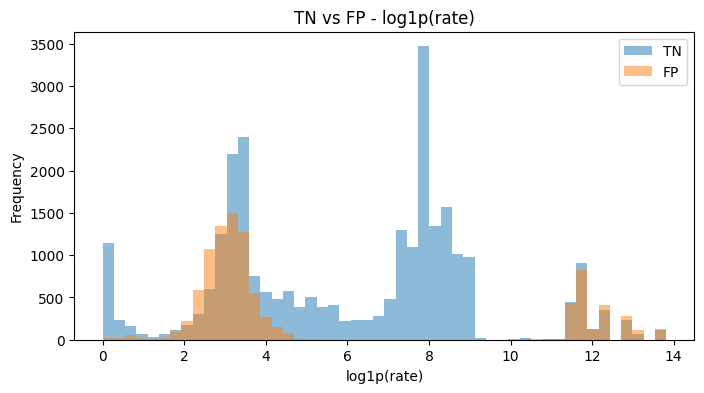

In [275]:
# Dùng Log1p để trực quan hóa rõ ràng hơn
plot_features = ["ackdat", "tcprtt", "dload", "rate"]

for col in plot_features:

    tn_values = tn[col].dropna()
    fp_values = fp[col].dropna()

    plt.figure(figsize=(8, 4))

    plt.hist(
        np.log1p(tn_values),
        bins=50,
        alpha=0.5,
        label="TN"
    )

    plt.hist(
        np.log1p(fp_values),
        bins=50,
        alpha=0.5,
        label="FP"
    )

    plt.title(f"TN vs FP - log1p({col})")
    plt.xlabel(f"log1p({col})")
    plt.ylabel("Frequency")
    plt.legend()

    plt.show()

In [276]:
# Tìm các object trong notebook có khả năng là preprocessing transformer
candidates = []

for name, obj in globals().items():
    if hasattr(obj, "get_feature_names_out"):
        candidates.append(name)

print("Các object có get_feature_names_out():")
print(candidates)

Các object có get_feature_names_out():
['OneHotEncoder', 'StandardScaler', 'encoder', 'baseline_encoder_test', 'candidate_encoder_test', 'ColumnTransformer', 'preprocessor_mc', 'final_preprocessor_mc', 'Pipeline']


In [277]:
feature_names = encoder.get_feature_names_out()

print("Số feature names:", len(feature_names))
print("Số feature importance:", len(rf_model.feature_importances_))

Số feature names: 155
Số feature importance: 186


In [278]:
encoded_feature_names = encoder.get_feature_names_out()

print("Encoded features:", len(encoded_feature_names))

Encoded features: 155


In [279]:
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()

print("Numerical features:", len(numeric_features))

Numerical features: 31


In [280]:
feature_names = (
    numeric_features
    + encoded_feature_names.tolist()
)

print("Total feature names:", len(feature_names))
print("RF importances:", len(rf_model.feature_importances_))

Total feature names: 186
RF importances: 186


In [281]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance.head(20))

,Feature,Importance
0,synack,0.082205
1,dload,0.074659
2,sload,0.057081
3,rate,0.056360
4,dbytes,0.048457
5,sbytes,0.047300
6,sinpkt,0.045308
7,ackdat,0.045215
8,dinpkt,0.043015
9,dur,0.042764


In [282]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("Train subset:", X_tr.shape)
print("Validation:", X_val.shape)
print("Attack rate - Train:", y_tr.mean())
print("Attack rate - Validation:", y_val.mean())

Train subset: (140272, 34)
Validation: (35069, 34)
Attack rate - Train: 0.680620508725904
Attack rate - Validation: 0.6806296159000826


In [283]:
categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumber of categorical features:", len(categorical_features))
print("Number of numerical features:", len(numeric_features))

Categorical features:
['proto', 'service', 'state']

Number of categorical features: 3
Number of numerical features: 31


In [284]:
def run_validation_experiment(drop_features=None):

    if drop_features is None:
        drop_features = []

    # Loại feature khỏi raw data
    X_tr_exp = X_tr.drop(columns=drop_features, errors="ignore").copy()
    X_val_exp = X_val.drop(columns=drop_features, errors="ignore").copy()

    # Xác định numerical / categorical sau khi bỏ feature
    cat_cols = X_tr_exp.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()

    num_cols = X_tr_exp.select_dtypes(
        include=["number"]
    ).columns.tolist()

    # Fit encoder CHỈ trên training subset
    encoder_exp = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )

    X_tr_cat = encoder_exp.fit_transform(X_tr_exp[cat_cols])
    X_val_cat = encoder_exp.transform(X_val_exp[cat_cols])

    # Numerical giữ nguyên
    X_tr_num = X_tr_exp[num_cols].to_numpy()
    X_val_num = X_val_exp[num_cols].to_numpy()

    # Ghép numerical + categorical
    X_tr_processed = np.hstack([
        X_tr_num,
        X_tr_cat
    ])

    X_val_processed = np.hstack([
        X_val_num,
        X_val_cat
    ])

    # Clone chính Random Forest baseline
    rf_exp = clone(rf_model)

    rf_exp.fit(X_tr_processed, y_tr)

    y_val_pred = rf_exp.predict(X_val_processed)

    cm = confusion_matrix(y_val, y_val_pred)

    tn_val, fp_val, fn_val, tp_val = cm.ravel()

    return {
        "Accuracy": accuracy_score(y_val, y_val_pred),
        "Precision_Normal": precision_score(
            y_val, y_val_pred, pos_label=0
        ),
        "Recall_Normal": recall_score(
            y_val, y_val_pred, pos_label=0
        ),
        "Precision_Attack": precision_score(
            y_val, y_val_pred, pos_label=1
        ),
        "Recall_Attack": recall_score(
            y_val, y_val_pred, pos_label=1
        ),
        "F1_Attack": f1_score(
            y_val, y_val_pred, pos_label=1
        ),
        "TN": tn_val,
        "FP": fp_val,
        "FN": fn_val,
        "TP": tp_val
    }

In [285]:
baseline_result = run_validation_experiment()

pd.DataFrame([baseline_result])

,Accuracy,Precision_Normal,Recall_Normal,Precision_Attack,Recall_Attack,F1_Attack,TN,FP,FN,TP
0,0.950098,0.940354,0.900893,0.954394,0.973187,0.963699,10090,1110,640,23229


In [286]:
result_no_tcp_timing = run_validation_experiment(
    drop_features=[
        "tcprtt",
        "synack",
        "ackdat"
    ]
)

pd.DataFrame([result_no_tcp_timing])

,Accuracy,Precision_Normal,Recall_Normal,Precision_Attack,Recall_Attack,F1_Attack,TN,FP,FN,TP
0,0.950726,0.939414,0.904018,0.955745,0.972642,0.96412,10125,1075,653,23216


In [287]:
result_no_tcp_seq = run_validation_experiment(
    drop_features=[
        "stcpb",
        "dtcpb"
    ]
)

pd.DataFrame([result_no_tcp_seq])

,Accuracy,Precision_Normal,Recall_Normal,Precision_Attack,Recall_Attack,F1_Attack,TN,FP,FN,TP
0,0.950412,0.940169,0.902143,0.954938,0.973061,0.963914,10104,1096,643,23226


In [288]:
result_no_tcp_all = run_validation_experiment(
    drop_features=[
        "tcprtt",
        "synack",
        "ackdat",
        "stcpb",
        "dtcpb"
    ]
)

pd.DataFrame([result_no_tcp_all])

,Accuracy,Precision_Normal,Recall_Normal,Precision_Attack,Recall_Attack,F1_Attack,TN,FP,FN,TP
0,0.95064,0.937934,0.905357,0.956303,0.971888,0.964033,10140,1060,671,23198


In [289]:
def train_and_evaluate_test(drop_features=None):

    if drop_features is None:
        drop_features = []

    # =========================
    # 1. Drop features
    # =========================
    X_train_exp = X_train.drop(
        columns=drop_features,
        errors="ignore"
    ).copy()

    X_test_exp = X_test.drop(
        columns=drop_features,
        errors="ignore"
    ).copy()

    # =========================
    # 2. Detect feature types
    # =========================
    cat_cols = X_train_exp.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()

    num_cols = X_train_exp.select_dtypes(
        include=["number"]
    ).columns.tolist()

    # =========================
    # 3. Fit encoder ONLY on full TRAIN
    # =========================
    encoder_final = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )

    X_train_cat = encoder_final.fit_transform(
        X_train_exp[cat_cols]
    )

    X_test_cat = encoder_final.transform(
        X_test_exp[cat_cols]
    )

    # =========================
    # 4. Numerical features
    # =========================
    X_train_num = X_train_exp[num_cols].to_numpy()
    X_test_num = X_test_exp[num_cols].to_numpy()

    # =========================
    # 5. Combine
    # =========================
    X_train_processed = np.hstack([
        X_train_num,
        X_train_cat
    ])

    X_test_processed = np.hstack([
        X_test_num,
        X_test_cat
    ])

    print("Train processed:", X_train_processed.shape)
    print("Test processed:", X_test_processed.shape)

    # =========================
    # 6. Train Random Forest
    # =========================
    model_final = clone(rf_model)

    model_final.fit(
        X_train_processed,
        y_train
    )

    # =========================
    # 7. Predict TEST
    # =========================
    y_test_pred = model_final.predict(
        X_test_processed
    )

    # =========================
    # 8. Metrics
    # =========================
    cm = confusion_matrix(
        y_test,
        y_test_pred
    )

    tn, fp, fn, tp = cm.ravel()

    result = {
        "Accuracy": accuracy_score(
            y_test,
            y_test_pred
        ),

        "Precision_Normal": precision_score(
            y_test,
            y_test_pred,
            pos_label=0
        ),

        "Recall_Normal": recall_score(
            y_test,
            y_test_pred,
            pos_label=0
        ),

        "Precision_Attack": precision_score(
            y_test,
            y_test_pred,
            pos_label=1
        ),

        "Recall_Attack": recall_score(
            y_test,
            y_test_pred,
            pos_label=1
        ),

        "F1_Attack": f1_score(
            y_test,
            y_test_pred,
            pos_label=1
        ),

        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

    return result, model_final, encoder_final

In [290]:
# Đánh giá Baseline trên test
baseline_test, baseline_model_test, baseline_encoder_test = (
    train_and_evaluate_test()
)

pd.DataFrame([baseline_test])

Train processed: (175341, 186)
Test processed: (82332, 186)


,Accuracy,Precision_Normal,Recall_Normal,Precision_Attack,Recall_Attack,F1_Attack,TN,FP,FN,TP
0,0.867172,0.955314,0.739,0.820201,0.971786,0.889582,27343,9657,1279,44053


In [291]:
# Đánh giá Cantidate trên Test
drop_features_final = [
    "tcprtt",
    "synack",
    "ackdat",
    "stcpb",
    "dtcpb"
]

candidate_test, candidate_model_test, candidate_encoder_test = (
    train_and_evaluate_test(
        drop_features=drop_features_final
    )
)

pd.DataFrame([candidate_test])

Train processed: (175341, 181)
Test processed: (82332, 181)


,Accuracy,Precision_Normal,Recall_Normal,Precision_Attack,Recall_Attack,F1_Attack,TN,FP,FN,TP
0,0.871411,0.953535,0.750432,0.826471,0.970154,0.892567,27766,9234,1353,43979


In [292]:
#  Test thử 2 model khi đứng cạnh nhau
comparison_test = pd.DataFrame([
    {
        "Model": "Baseline",
        **baseline_test
    },
    {
        "Model": "Candidate - remove 5 features",
        **candidate_test
    }
])

display(comparison_test)

,Model,Accuracy,Precision_Normal,Recall_Normal,Precision_Attack,Recall_Attack,F1_Attack,TN,FP,FN,TP
0,Baseline,0.867172,0.955314,0.739000,0.820201,0.971786,0.889582,27343,9657,1279,44053
1,Candidate - remove 5 features,0.871411,0.953535,0.750432,0.826471,0.970154,0.892567,27766,9234,1353,43979


In [293]:
# Kiểm tra lại các Columns sau khi đã loại bỏ các candidate => ("tcprtt","synack","ackdat","stcpb","dtcpb")
X_train.drop(columns=drop_features_final).columns

Index(['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt',
       'dinpkt', 'sjit', 'djit', 'swin', 'dwin', 'smean', 'dmean',
       'trans_depth', 'response_body_len', 'ct_src_dport_ltm',
       'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd',
       'is_sm_ips_ports'],
      dtype='object')

# Kiểm tra lại model, Multiclass và tiến hành huấn luyện model

In [294]:
# Tìm các DataFrame hiện đang có cột attack_cat

for name, obj in globals().items():
    if isinstance(obj, pd.DataFrame):
        if "attack_cat" in obj.columns:
            print(
                f"{name}: "
                f"shape={obj.shape}, "
                f"attack_cat found"
            )

df_test: shape=(82332, 36), attack_cat found
df_train: shape=(175341, 36), attack_cat found
full_df: shape=(257673, 36), attack_cat found
_3: shape=(5, 36), attack_cat found
_4: shape=(5, 36), attack_cat found
normal_df: shape=(56000, 36), attack_cat found
attack_df: shape=(119341, 36), attack_cat found
tn_df: shape=(27343, 36), attack_cat found
fp_df: shape=(9657, 36), attack_cat found
train_normal: shape=(56000, 36), attack_cat found
test_normal: shape=(37000, 36), attack_cat found
df_test_analysis: shape=(82332, 37), attack_cat found
fp: shape=(9657, 37), attack_cat found
tn: shape=(27343, 37), attack_cat found
_80: shape=(5, 36), attack_cat found
_81: shape=(5, 36), attack_cat found
_156: shape=(5, 36), attack_cat found
_157: shape=(5, 36), attack_cat found
_235: shape=(5, 36), attack_cat found
_236: shape=(5, 36), attack_cat found


In [295]:
# Phân bố các lớp attack_cat trong TRAIN

attack_cat_counts = df_train["attack_cat"].value_counts(dropna=False)

print("=== Phân bố attack_cat trong TRAIN ===")
print(attack_cat_counts)

print("\n=== Tỷ lệ (%) ===")
print(
    (df_train["attack_cat"].value_counts(normalize=True, dropna=False) * 100)
    .round(3)
)

=== Phân bố attack_cat trong TRAIN ===
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64

=== Tỷ lệ (%) ===
attack_cat
Normal            31.938
Generic           22.813
Exploits          19.045
Fuzzers           10.371
DoS                6.994
Reconnaissance     5.983
Analysis           1.141
Backdoor           0.996
Shellcode          0.646
Worms              0.074
Name: proportion, dtype: float64


In [296]:
# Độ khớp giữa X_train và df_train
print("X_train shape:", X_train.shape)
print("df_train shape:", df_train.shape)

print("\nIndex X_train == df_train:",
      X_train.index.equals(df_train.index))

print("\nCác feature trong X_train có nằm trong df_train không:",
      set(X_train.columns).issubset(df_train.columns))

X_train shape: (175341, 34)
df_train shape: (175341, 36)

Index X_train == df_train: True

Các feature trong X_train có nằm trong df_train không: True


In [297]:
y_multiclass = df_train.loc[X_train.index, "attack_cat"]

In [298]:
# ==========================================
# TẠO DATASET MULTICLASS CHỈ CHO ATTACK
# ==========================================

# Lấy attack_cat tương ứng với X_train
y_attack_cat = df_train.loc[X_train.index, "attack_cat"]

# Chỉ giữ các dòng thực sự là Attack
attack_mask = y_attack_cat != "Normal"

X_attack = X_train.loc[attack_mask].copy()
y_attack = y_attack_cat.loc[attack_mask].copy()

print("=== Multiclass Attack Dataset ===")
print("X_attack shape:", X_attack.shape)
print("y_attack shape:", y_attack.shape)

print("\n=== Phân bố các Attack class ===")
print(y_attack.value_counts())

print("\n=== Tỷ lệ (%) ===")
print(
    (y_attack.value_counts(normalize=True) * 100)
    .round(3)
)

=== Multiclass Attack Dataset ===
X_attack shape: (119341, 34)
y_attack shape: (119341,)

=== Phân bố các Attack class ===
attack_cat
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Normal                0
Name: count, dtype: int64

=== Tỷ lệ (%) ===
attack_cat
Generic           33.517
Exploits          27.981
Fuzzers           15.237
DoS               10.276
Reconnaissance     8.791
Analysis           1.676
Backdoor           1.463
Shellcode          0.949
Worms              0.109
Normal             0.000
Name: proportion, dtype: float64


In [299]:
# ==========================================
# MULTICLASS TRAIN / VALIDATION SPLIT
# ==========================================

X_attack_train, X_attack_val, y_attack_train, y_attack_val = train_test_split(
    X_attack,
    y_attack,
    test_size=0.20,
    random_state=42,
    stratify=y_attack
)

print("=== Multiclass split ===")
print("Train:", X_attack_train.shape)
print("Validation:", X_attack_val.shape)

print("\n=== Train class distribution ===")
print(y_attack_train.value_counts())

print("\n=== Validation class distribution ===")
print(y_attack_val.value_counts())

=== Multiclass split ===
Train: (95472, 34)
Validation: (23869, 34)

=== Train class distribution ===
attack_cat
Generic           32000
Exploits          26714
Fuzzers           14547
DoS                9811
Reconnaissance     8393
Analysis           1600
Backdoor           1397
Shellcode           906
Worms               104
Normal                0
Name: count, dtype: int64

=== Validation class distribution ===
attack_cat
Generic           8000
Exploits          6679
Fuzzers           3637
DoS               2453
Reconnaissance    2098
Analysis           400
Backdoor           349
Shellcode          227
Worms               26
Normal               0
Name: count, dtype: int64


# Train Multiclass model

In [300]:
# ==========================================
# MULTICLASS FEATURE SET
# ==========================================

drop_features_multiclass = [
    "tcprtt",
    "synack",
    "ackdat",
    "stcpb",
    "dtcpb"
]

X_attack_train_mc = X_attack_train.drop(
    columns=drop_features_multiclass
).copy()

X_attack_val_mc = X_attack_val.drop(
    columns=drop_features_multiclass
).copy()

print("Original features:", X_attack_train.shape[1])
print("Features after drop:", X_attack_train_mc.shape[1])

print("\nCategorical features:")
print(
    X_attack_train_mc.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()
)

print("\nNumerical features:",
      X_attack_train_mc.select_dtypes(
          exclude=["object", "category"]
      ).shape[1])

Original features: 34
Features after drop: 29

Categorical features:
['proto', 'service', 'state']

Numerical features: 26


In [301]:
# ==========================================
# MULTICLASS PREPROCESSOR
# ==========================================

categorical_features_mc = [
    "proto",
    "service",
    "state"
]

numerical_features_mc = [
    col for col in X_attack_train_mc.columns
    if col not in categorical_features_mc
]

preprocessor_mc = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features_mc
        ),
        (
            "num",
            "passthrough",
            numerical_features_mc
        )
    ]
)

# Fit CHỈ trên multiclass TRAIN
X_attack_train_encoded = preprocessor_mc.fit_transform(
    X_attack_train_mc
)

# Validation chỉ transform, KHÔNG fit lại
X_attack_val_encoded = preprocessor_mc.transform(
    X_attack_val_mc
)

print("=== Multiclass preprocessing ===")
print("Train encoded shape:", X_attack_train_encoded.shape)
print("Validation encoded shape:", X_attack_val_encoded.shape)

=== Multiclass preprocessing ===
Train encoded shape: (95472, 173)
Validation encoded shape: (23869, 173)


In [302]:
# ==========================================
# MULTICLASS RANDOM FOREST - BASELINE
# ==========================================

rf_multiclass = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

print("Training multiclass Random Forest...")

rf_multiclass.fit(
    X_attack_train_encoded,
    y_attack_train
)

print("Training completed!")

Training multiclass Random Forest...
Training completed!


In [303]:
# ==========================================
# MULTICLASS VALIDATION EVALUATION
# ==========================================

y_attack_val_pred = rf_multiclass.predict(
    X_attack_val_encoded
)

accuracy_mc = accuracy_score(
    y_attack_val,
    y_attack_val_pred
)

macro_f1_mc = f1_score(
    y_attack_val,
    y_attack_val_pred,
    average="macro"
)

weighted_f1_mc = f1_score(
    y_attack_val,
    y_attack_val_pred,
    average="weighted"
)

print("=== MULTICLASS VALIDATION ===")
print(f"Accuracy   : {accuracy_mc:.6f}")
print(f"Macro-F1   : {macro_f1_mc:.6f}")
print(f"Weighted-F1: {weighted_f1_mc:.6f}")

print("\n=== Classification Report ===")

print(
    classification_report(
        y_attack_val,
        y_attack_val_pred,
        digits=4,
        zero_division=0
    )
)

=== MULTICLASS VALIDATION ===
Accuracy   : 0.734048
Macro-F1   : 0.554663
Weighted-F1: 0.770112

=== Classification Report ===
                precision    recall  f1-score   support

      Analysis     0.0893    0.2750    0.1348       400
      Backdoor     0.0435    0.2464    0.0739       349
           DoS     0.2976    0.3587    0.3253      2453
      Exploits     0.8317    0.5562    0.6666      6679
       Fuzzers     0.9224    0.8760    0.8986      3637
       Generic     0.9973    0.9806    0.9889      8000
Reconnaissance     0.9174    0.7469    0.8234      2098
     Shellcode     0.6368    0.5330    0.5803       227
         Worms     0.6111    0.4231    0.5000        26

      accuracy                         0.7340     23869
     macro avg     0.5941    0.5551    0.5547     23869
  weighted avg     0.8276    0.7340    0.7701     23869



Class order:
['Analysis' 'Backdoor' 'DoS' 'Exploits' 'Fuzzers' 'Generic'
 'Reconnaissance' 'Shellcode' 'Worms']

Confusion Matrix:
[[ 110   99  159   32    0    0    0    0    0]
 [  59   86  172   21    6    0    2    3    0]
 [ 417  736  880  350   43    4   11   12    0]
 [ 519  821 1356 3715  121    8  121   14    4]
 [  61   87  170   82 3186    8    4   37    2]
 [   7   27   30   76   13 7845    0    2    0]
 [  59  121  187  158    4    0 1567    1    1]
 [   0    0    3   18   81    1    3  121    0]
 [   0    0    0   15    0    0    0    0   11]]


<Figure size 1000x800 with 0 Axes>

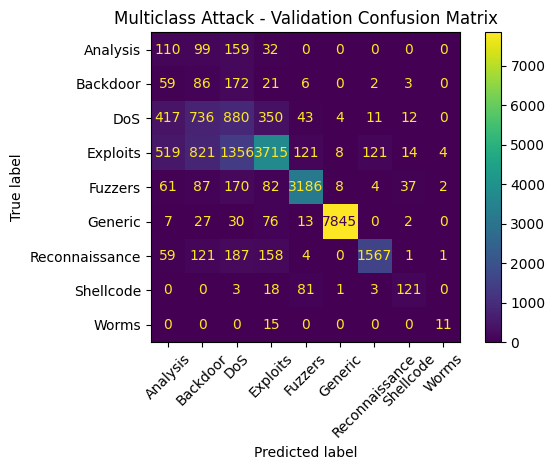

In [304]:
# ==========================================
# MULTICLASS CONFUSION MATRIX
# ==========================================

class_names = rf_multiclass.classes_

cm = confusion_matrix(
    y_attack_val,
    y_attack_val_pred,
    labels=class_names
)

print("Class order:")
print(class_names)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    xticks_rotation=45,
    values_format="d"
)

plt.title("Multiclass Attack - Validation Confusion Matrix")
plt.tight_layout()
plt.show()

In [305]:
# ==========================================
# RANDOM FOREST - BALANCED SUBSAMPLE
# ==========================================

rf_multiclass_bs = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

print("Training Random Forest (balanced_subsample)...")

rf_multiclass_bs.fit(
    X_attack_train_encoded,
    y_attack_train
)

print("Training completed!")

# Validation prediction
y_attack_val_pred_bs = rf_multiclass_bs.predict(
    X_attack_val_encoded
)

# Metrics
accuracy_bs = accuracy_score(
    y_attack_val,
    y_attack_val_pred_bs
)

macro_f1_bs = f1_score(
    y_attack_val,
    y_attack_val_pred_bs,
    average="macro"
)

weighted_f1_bs = f1_score(
    y_attack_val,
    y_attack_val_pred_bs,
    average="weighted"
)

print("\n=== RANDOM FOREST BALANCED SUBSAMPLE ===")
print(f"Accuracy    : {accuracy_bs:.6f}")
print(f"Macro-F1    : {macro_f1_bs:.6f}")
print(f"Weighted-F1 : {weighted_f1_bs:.6f}")

print("\n=== Classification Report ===")

print(
    classification_report(
        y_attack_val,
        y_attack_val_pred_bs,
        digits=4,
        zero_division=0
    )
)

Training Random Forest (balanced_subsample)...
Training completed!

=== RANDOM FOREST BALANCED SUBSAMPLE ===
Accuracy    : 0.734174
Macro-F1    : 0.556245
Weighted-F1 : 0.770370

=== Classification Report ===
                precision    recall  f1-score   support

      Analysis     0.0891    0.2750    0.1346       400
      Backdoor     0.0425    0.2407    0.0723       349
           DoS     0.2986    0.3612    0.3269      2453
      Exploits     0.8329    0.5561    0.6669      6679
       Fuzzers     0.9227    0.8763    0.8989      3637
       Generic     0.9973    0.9806    0.9889      8000
Reconnaissance     0.9169    0.7464    0.8229      2098
     Shellcode     0.6436    0.5330    0.5831       227
         Worms     0.6471    0.4231    0.5116        26

      accuracy                         0.7342     23869
     macro avg     0.5990    0.5547    0.5562     23869
  weighted avg     0.8281    0.7342    0.7704     23869



In [306]:
# ==========================================
# FINAL MULTICLASS MODEL
# Train trên TOÀN BỘ Attack training data
# ==========================================
# ------------------------------------------
# 1. Feature set
# ------------------------------------------

drop_features_final_mc = [
    "tcprtt",
    "synack",
    "ackdat",
    "stcpb",
    "dtcpb"
]

X_attack_full_mc = X_attack.drop(
    columns=drop_features_final_mc
).copy()

# ------------------------------------------
# 2. Features
# ------------------------------------------

categorical_features_final_mc = [
    "proto",
    "service",
    "state"
]

numerical_features_final_mc = [
    col for col in X_attack_full_mc.columns
    if col not in categorical_features_final_mc
]

# ------------------------------------------
# 3. Final preprocessing
# ------------------------------------------

final_preprocessor_mc = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features_final_mc
        ),
        (
            "num",
            "passthrough",
            numerical_features_final_mc
        )
    ]
)

X_attack_full_encoded = final_preprocessor_mc.fit_transform(
    X_attack_full_mc
)

print("=== FINAL MULTICLASS PREPROCESSING ===")
print("Raw features:", X_attack_full_mc.shape)
print("Encoded features:", X_attack_full_encoded.shape)

# ------------------------------------------
# 4. Final Random Forest
# ------------------------------------------

final_multiclass_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

print("\nTraining FINAL multiclass model...")

final_multiclass_model.fit(
    X_attack_full_encoded,
    y_attack
)

print("Final multiclass training completed!")

=== FINAL MULTICLASS PREPROCESSING ===
Raw features: (119341, 29)
Encoded features: (119341, 173)

Training FINAL multiclass model...
Final multiclass training completed!


In [307]:
# ==========================================
# FINAL MULTICLASS TEST EVALUATION
# ==========================================

# 1. Lấy Attack samples từ TEST
test_attack_mask = df_test["label"] == 1

X_test_attack = df_test.loc[
    test_attack_mask,
    X_attack.columns
].copy()

y_test_attack = df_test.loc[
    test_attack_mask,
    "attack_cat"
].copy()

print("=== FINAL MULTICLASS TEST DATA ===")
print("X_test_attack:", X_test_attack.shape)
print("y_test_attack:", y_test_attack.shape)

print("\nAttack class distribution:")
print(y_test_attack.value_counts())

=== FINAL MULTICLASS TEST DATA ===
X_test_attack: (45332, 34)
y_test_attack: (45332,)

Attack class distribution:
attack_cat
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Normal                0
Name: count, dtype: int64


In [308]:
# ==========================================
# FINAL MULTICLASS TEST EVALUATION
# ==========================================
# 1. Drop đúng 5 features
X_test_attack_mc = X_test_attack.drop(
    columns=drop_features_final_mc
).copy()

# 2. Transform bằng FINAL encoder
#    KHÔNG fit lại trên Test
X_test_attack_encoded = final_preprocessor_mc.transform(
    X_test_attack_mc
)

print("=== TEST PREPROCESSING ===")
print(
    "Test encoded shape:",
    X_test_attack_encoded.shape
)

# 3. Prediction
y_test_attack_pred = final_multiclass_model.predict(
    X_test_attack_encoded
)

# 4. Metrics
accuracy_test_mc = accuracy_score(
    y_test_attack,
    y_test_attack_pred
)

macro_f1_test_mc = f1_score(
    y_test_attack,
    y_test_attack_pred,
    average="macro"
)

weighted_f1_test_mc = f1_score(
    y_test_attack,
    y_test_attack_pred,
    average="weighted"
)

print("\n=== FINAL MULTICLASS TEST ===")
print(f"Accuracy    : {accuracy_test_mc:.6f}")
print(f"Macro-F1    : {macro_f1_test_mc:.6f}")
print(f"Weighted-F1 : {weighted_f1_test_mc:.6f}")

print("\n=== Classification Report ===")

print(
    classification_report(
        y_test_attack,
        y_test_attack_pred,
        digits=4,
        zero_division=0
    )
)

=== TEST PREPROCESSING ===
Test encoded shape: (45332, 173)

=== FINAL MULTICLASS TEST ===
Accuracy    : 0.763390
Macro-F1    : 0.526199
Weighted-F1 : 0.794180

=== Classification Report ===
                precision    recall  f1-score   support

      Analysis     0.0190    0.0089    0.0121       677
      Backdoor     0.0347    0.2796    0.0617       583
           DoS     0.2878    0.2974    0.2925      4089
      Exploits     0.8115    0.6611    0.7286     11132
       Fuzzers     0.8534    0.7547    0.8010      6062
       Generic     0.9986    0.9690    0.9836     18871
Reconnaissance     0.9320    0.7995    0.8607      3496
     Shellcode     0.5823    0.5053    0.5411       378
         Worms     0.6818    0.3409    0.4545        44

      accuracy                         0.7634     45332
     macro avg     0.5779    0.5129    0.5262     45332
  weighted avg     0.8332    0.7634    0.7942     45332



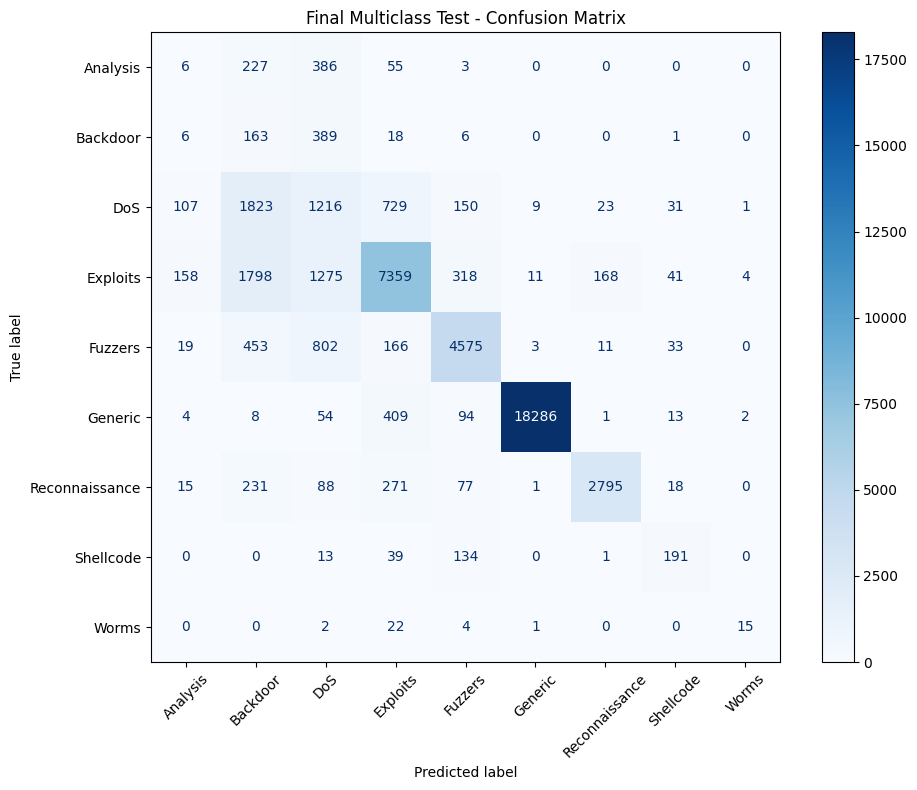

In [309]:
# ==========================================
# FINAL MULTICLASS CONFUSION MATRIX
# ==========================================
labels_mc = [
    "Analysis",
    "Backdoor",
    "DoS",
    "Exploits",
    "Fuzzers",
    "Generic",
    "Reconnaissance",
    "Shellcode",
    "Worms"
]

fig, ax = plt.subplots(figsize=(10, 8))

ConfusionMatrixDisplay.from_predictions(
    y_test_attack,
    y_test_attack_pred,
    labels=labels_mc,
    display_labels=labels_mc,
    xticks_rotation=45,
    cmap="Blues",
    ax=ax
)

ax.set_title("Final Multiclass Test - Confusion Matrix")
plt.tight_layout()
plt.show()

In [319]:
"""
nids_pipeline_v2.py - NIDS 2 tang (Binary Gatekeeper -> Multiclass Attack-type), UNSW-NB15

Kien truc (theo lua chon cua ban):
  Stage 1 (binary)     : Normal vs Attack, train tren TOAN BO train set.
  Stage 2 (multiclass) : loai tan cong cu the, train CHI tren cac dong Attack.
  Luc suy luan: chay Stage 1 truoc. Neu risk (=P(Attack)) < nguong -> "Normal".
  Neu >= nguong -> chay Stage 2 de ra loai tan cong.

  Luu y quan trong ve loi cong don: neu Stage 1 bao nham 1 flow Normal la Attack,
  Stage 2 buoc phai chon 1 loai tan cong (no khong co lua chon "Normal"). Ham
  predict_flow() danh dau nhung truong hop nay bang "gatekeeper_risk" thap gan
  nguong, de chatbot/UI co the canh bao do tin cay thap thay vi khang dinh chac chan.

Form dau vao (14 truong, mo rong so voi 7 truong ban dau theo yeu cau cua ban):
  proto, service, state,
  dur, spkts, dpkts, sbytes, dbytes,
  sloss, dloss, swin, dwin, ct_src_dport_ltm, ct_dst_sport_ltm

  Co tinh CHU Y khi chon mo rong: notebook cua ban da chung minh bang thuc nghiem
  rang tcprtt/synack/ackdat/stcpb/dtcpb la nhung dac trung LECH PHAN PHOI manh
  nhat giua train va test (KS-test), va bo chung giup Recall_Normal tang. Vi vay
  file nay KHONG dua 5 truong do tro lai form, du chung nam trong top feature
  importance. Cac truong duoc them (sloss, dloss, swin, dwin, ct_src_dport_ltm,
  ct_dst_sport_ltm) la cac chi so dem/kich thuoc it bi lech hon.

Chay huan luyen (tren Kaggle):
    python nids_pipeline_v2.py \
        --train /kaggle/input/datasets/dhoogla/unswnb15/UNSW_NB15_training-set.parquet \
        --test  /kaggle/input/datasets/dhoogla/unswnb15/UNSW_NB15_testing-set.parquet

Dung trong Streamlit:
    from nids_pipeline_v2 import load_bundle, predict_flow, risk_badge
    bundle = load_bundle("nids_bundle_v2.joblib")
    result = predict_flow(bundle, {...14 truong...})[0]
"""
from __future__ import annotations

import argparse

import joblib
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

# ----------------------------------------------------------------------------------------
# Cau hinh
# ----------------------------------------------------------------------------------------
CAT_COLS = ["proto", "service", "state"]
RAW_NUM_COLS = [
    "dur", "spkts", "dpkts", "sbytes", "dbytes",
    "sloss", "dloss", "swin", "dwin",
    "ct_src_dport_ltm", "ct_dst_sport_ltm",
]
DERIVED_COLS = ["rate", "smean", "dmean", "sload", "dload"]
NUM_COLS = RAW_NUM_COLS + DERIVED_COLS
FEATURES = CAT_COLS + NUM_COLS              # dung chung cho ca 2 stage
USER_INPUT_COLS = CAT_COLS + RAW_NUM_COLS    # 14 truong nguoi dung nhap

TOP_N_PROTO = 6
NORMAL = "Normal"
GATE_THRESHOLD = 0.5     # nguong Stage 1: risk >= nguong -> coi la Attack
RANDOM_STATE = 42


# ----------------------------------------------------------------------------------------
# Dac trung (dung chung train/app)
# ----------------------------------------------------------------------------------------
def build_features(df: pd.DataFrame, top_protos: list[str]) -> pd.DataFrame:
    out = pd.DataFrame(index=df.index)
    out["proto"] = df["proto"].astype(str).str.strip().str.lower()
    out["proto"] = out["proto"].where(out["proto"].isin(top_protos), "other")
    out["service"] = df["service"].astype(str).str.strip().str.lower()
    out["state"] = df["state"].astype(str).str.strip().str.upper()
    for c in RAW_NUM_COLS:
        out[c] = pd.to_numeric(df[c]).astype("float64")

    dur, spk, dpk = out["dur"], out["spkts"], out["dpkts"]
    sby, dby = out["sbytes"], out["dbytes"]
    has_dur = dur > 0
    safe_dur = dur.where(has_dur, 1.0)

    out["rate"] = np.where(has_dur, (spk + dpk - 1).clip(lower=0) / safe_dur, 0.0)
    out["smean"] = np.where(spk > 0, sby / spk.where(spk > 0, 1.0), 0.0)
    out["dmean"] = np.where(dpk > 0, dby / dpk.where(dpk > 0, 1.0), 0.0)
    out["sload"] = np.where(has_dur, sby * 8 / safe_dur, 0.0)
    out["dload"] = np.where(has_dur, dby * 8 / safe_dur, 0.0)
    return out[FEATURES]


# ----------------------------------------------------------------------------------------
# Pipeline / model
# ----------------------------------------------------------------------------------------
def make_pipeline(model) -> Pipeline:
    prep = ColumnTransformer(
        [
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT_COLS),
            ("num", "passthrough", NUM_COLS),
        ]
    )
    return Pipeline([("prep", prep), ("clf", model)])


def candidate_models() -> dict:
    return {
        "RandomForest": RandomForestClassifier(
            n_estimators=200, min_samples_leaf=2, n_jobs=-1,
            class_weight="balanced_subsample", random_state=RANDOM_STATE,
        ),
        "XGBoost": XGBClassifier(
            n_estimators=300, max_depth=8, learning_rate=0.1, subsample=0.8,
            colsample_bytree=0.8, tree_method="hist", n_jobs=-1,
            random_state=RANDOM_STATE, eval_metric="logloss",
        ),
    }


def _weights(y) -> np.ndarray:
    return compute_sample_weight("balanced", y)


def _fit(pipe: Pipeline, X, y) -> Pipeline:
    pipe.fit(X, y, clf__sample_weight=_weights(y))
    return pipe


# ----------------------------------------------------------------------------------------
# Huan luyen
# ----------------------------------------------------------------------------------------
def train(tr: pd.DataFrame, te: pd.DataFrame, out_path: str = "nids_bundle_v2.joblib") -> dict:
    top_protos = (
        tr["proto"].astype(str).str.strip().str.lower().value_counts().head(TOP_N_PROTO).index.tolist()
    )
    Xtr_all = build_features(tr, top_protos)
    ytr_bin = tr["label"].astype(int).to_numpy()
    Xte_all = build_features(te, top_protos)
    yte_bin = te["label"].astype(int).to_numpy()

    # ============================== STAGE 1: BINARY ==============================
    Xa, Xv, ya, yv = train_test_split(
        Xtr_all, ytr_bin, test_size=0.2, stratify=ytr_bin, random_state=RANDOM_STATE
    )
    bin_scores = {}
    for name, model in candidate_models().items():
        pipe = _fit(make_pipeline(model), Xa, ya)
        pred_v = pipe.predict(Xv)
        # uu tien Recall_Normal vi day la metric bi anh huong nang nhat boi distribution shift
        bin_scores[name] = recall_score(yv, pred_v, pos_label=0)
        print(f"[val][Stage1] {name}: Recall_Normal={bin_scores[name]:.4f}")
    best_bin = max(bin_scores, key=bin_scores.get)
    print(f"[i] Stage1 chon: {best_bin}")

    stage1 = _fit(make_pipeline(candidate_models()[best_bin]), Xtr_all, ytr_bin)
    proba1 = stage1.predict_proba(Xte_all)
    normal_col = list(stage1.classes_).index(0)
    risk = 1.0 - proba1[:, normal_col]
    pred_bin = (risk >= GATE_THRESHOLD).astype(int)

    print("\n=== TEST Stage1 (Normal vs Attack) ===")
    print(classification_report(yte_bin, pred_bin, target_names=["Normal", "Attack"], digits=3))
    cm1 = confusion_matrix(yte_bin, pred_bin)
    print(pd.DataFrame(cm1, index=["Normal", "Attack"], columns=["pred_Normal", "pred_Attack"]))

    # ============================== STAGE 2: MULTICLASS (chi Attack) ==============================
    attack_mask_tr = tr["attack_cat"].astype(str) != NORMAL
    Xatk, yatk_raw = Xtr_all[attack_mask_tr], tr.loc[attack_mask_tr, "attack_cat"].astype(str)
    le = LabelEncoder().fit(yatk_raw)
    yatk = le.transform(yatk_raw)

    Xaa, Xav, yaa, yav = train_test_split(
        Xatk, yatk, test_size=0.2, stratify=yatk, random_state=RANDOM_STATE
    )
    mc_scores = {}
    for name, model in candidate_models().items():
        pipe = _fit(make_pipeline(model), Xaa, yaa)
        mc_scores[name] = f1_score(yav, pipe.predict(Xav), average="macro")
        print(f"[val][Stage2] {name}: macro-F1={mc_scores[name]:.4f}")
    best_mc = max(mc_scores, key=mc_scores.get)
    print(f"[i] Stage2 chon: {best_mc}")

    stage2 = _fit(make_pipeline(candidate_models()[best_mc]), Xatk, yatk)

    # Danh gia Stage2 CHI tren cac dong Attack that su cua test (dung nhu notebook cua ban)
    attack_mask_te = te["attack_cat"].astype(str) != NORMAL
    Xte_atk = Xte_all[attack_mask_te]
    yte_atk = le.transform(te.loc[attack_mask_te, "attack_cat"].astype(str))
    pred_atk = stage2.predict(Xte_atk)
    print("\n=== TEST Stage2 (chi tren Attack that) ===")
    print(classification_report(yte_atk, pred_atk, target_names=le.classes_, digits=3, zero_division=0))

    # Danh gia PIPELINE END-TO-END: chay Stage1 -> Stage2 tren TOAN BO test (ca Normal lan Attack)
    # de do loi cong don thuc te khi trien khai.
    final_label = np.where(pred_bin == 0, NORMAL, "")
    if pred_bin.sum() > 0:
        pred_atk_all = stage2.predict(Xte_all[pred_bin == 1])
        final_label[pred_bin == 1] = le.inverse_transform(pred_atk_all)
    true_label = te["attack_cat"].astype(str).to_numpy()
    e2e_acc = (final_label == true_label).mean()
    e2e_normal_recall = (final_label[true_label == NORMAL] == NORMAL).mean()
    print(f"\n=== END-TO-END (Stage1 -> Stage2, toan bo test) ===")
    print(f"Accuracy tong the (10 lop): {e2e_acc:.3f}")
    print(f"Recall Normal (khong bi Stage1 bao nham): {e2e_normal_recall:.3f}")

    bundle = {
        "stage1": stage1, "stage2": stage2, "label_encoder_stage2": le,
        "top_protos": top_protos, "features": FEATURES,
        "stage1_model": best_bin, "stage2_model": best_mc,
        "choices": {
            "proto": top_protos + ["other"],
            "service": sorted(tr["service"].astype(str).str.lower().unique().tolist()),
            "state": sorted(tr["state"].astype(str).str.upper().unique().tolist()),
        },
    }
    joblib.dump(bundle, out_path, compress=3)
    print(f"\n[i] Da luu: {out_path}")
    return bundle


# ----------------------------------------------------------------------------------------
# Suy luan (Streamlit)
# ----------------------------------------------------------------------------------------
def load_bundle(path: str = "nids_bundle_v2.joblib") -> dict:
    return joblib.load(path)


def _validate(df: pd.DataFrame) -> None:
    missing = [c for c in USER_INPUT_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"Thieu cot: {missing}")
    nums = df[RAW_NUM_COLS].apply(pd.to_numeric, errors="coerce")
    if nums.isna().any().any():
        raise ValueError("Co gia tri so bi trong hoac khong hop le.")
    if (nums < 0).any().any():
        raise ValueError("Cac chi so khong duoc am.")
    if (nums["spkts"] < 1).any():
        raise ValueError("spkts phai >= 1.")


def risk_badge(risk: float) -> tuple[str, str]:
    if risk < 0.3:
        return "THAP", "green"
    if risk < 0.7:
        return "TRUNG BINH", "orange"
    return "CAO", "red"


def predict_flow(bundle: dict, flows) -> list[dict]:
    df = pd.DataFrame([flows]) if isinstance(flows, dict) else pd.DataFrame(flows).reset_index(drop=True)
    _validate(df)
    X = build_features(df, bundle["top_protos"])

    proba1 = bundle["stage1"].predict_proba(X)
    normal_col = list(bundle["stage1"].classes_).index(0)
    risk = 1.0 - proba1[:, normal_col]
    is_attack = risk >= GATE_THRESHOLD

    classes2 = list(bundle["label_encoder_stage2"].classes_)
    results = []
    for i in range(len(X)):
        badge, color = risk_badge(float(risk[i]))
        row = {
            "gatekeeper_risk": float(risk[i]),  # P(Attack) tu Stage 1
            "badge": badge,
            "color": color,
            "features": X.iloc[i].to_dict(),
        }
        if not is_attack[i]:
            row["label"] = NORMAL
            row["attack_type_confidence"] = None
            row["attack_probabilities"] = None
        else:
            p2 = bundle["stage2"].predict_proba(X.iloc[[i]])[0]
            k = int(np.argmax(p2))
            row["label"] = classes2[k]
            row["attack_type_confidence"] = float(p2[k])
            row["attack_probabilities"] = {c: float(p) for c, p in zip(classes2, p2)}
            # Canh bao: neu gatekeeper_risk chi vua qua nguong, day co the la 1 flow
            # Normal bi Stage1 bao nham, va nhan attack type o day khong dang tin cay.
            row["low_confidence_gate"] = bool(risk[i] < 0.65)
        results.append(row)
    return results

In [326]:
bundle = train(df_train, df_test, out_path="nids_bundle_v2.joblib")

[val][Stage1] RandomForest: Recall_Normal=0.9503
[val][Stage1] XGBoost: Recall_Normal=0.9491
[i] Stage1 chon: RandomForest

=== TEST Stage1 (Normal vs Attack) ===
              precision    recall  f1-score   support

      Normal      0.928     0.863     0.894     37000
      Attack      0.894     0.945     0.919     45332

    accuracy                          0.908     82332
   macro avg      0.911     0.904     0.907     82332
weighted avg      0.909     0.908     0.908     82332

        pred_Normal  pred_Attack
Normal        31920         5080
Attack         2480        42852
[val][Stage2] RandomForest: macro-F1=0.5664
[val][Stage2] XGBoost: macro-F1=0.5840
[i] Stage2 chon: XGBoost

=== TEST Stage2 (chi tren Attack that) ===
                precision    recall  f1-score   support

      Analysis      0.088     0.106     0.096       677
      Backdoor      0.055     0.491     0.098       583
           DoS      0.343     0.312     0.327      4089
      Exploits      0.876     0.60

In [327]:
top_protos = bundle["top_protos"]
le = bundle["label_encoder_stage2"]
Xte_all = build_features(df_test, top_protos)

proba1 = bundle["stage1"].predict_proba(Xte_all)
normal_col = list(bundle["stage1"].classes_).index(0)
risk = 1.0 - proba1[:, normal_col]
pred_bin = (risk >= 0.5).astype(int)

# Sửa lỗi: ép dtype=object để không bị cắt chuỗi
final_label = np.where(pred_bin == 0, "Normal", "").astype(object)
if pred_bin.sum() > 0:
    pred_atk_all = bundle["stage2"].predict(Xte_all[pred_bin == 1])
    final_label[pred_bin == 1] = le.inverse_transform(pred_atk_all)

true_label = df_test["attack_cat"].astype(str).to_numpy()
e2e_acc = (final_label == true_label).mean()
e2e_normal_recall = (final_label[true_label == "Normal"] == "Normal").mean()
print(f"Accuracy tong the (10 lop): {e2e_acc:.3f}")
print(f"Recall Normal: {e2e_normal_recall:.3f}")

Accuracy tong the (10 lop): 0.782
Recall Normal: 0.863


# Giảng viên gợi ý

In [331]:
# Gợi ý 
# 2. HÀM TẠO ĐẶC TRƯNG MẠNG PHÁI SINH
def add_network_features(df):
    d = df.copy()
    dur = d['dur'].clip(lower=0.00001)
    d['rate'] = (d['spkts'] + d['dpkts']) / dur
    d['sload_rate'] = d['sbytes'] / dur
    d['dload_rate'] = d['dbytes'] / dur
    d['byte_ratio'] = (d['sbytes'] + 1) / (d['dbytes'] + 1)
    return d

train_df = add_network_features(df_train)
test_df = add_network_features(df_test)

# 3. CHỌN ĐẶC TRƯNG VÀ MÃ HÓA NHÃN MỤC TIÊU
num_cols = ['dur', 'sbytes', 'dbytes', 'sloss', 'dloss', 'rate', 'sload_rate', 'dload_rate', 'byte_ratio']
cat_cols = ['proto', 'service', 'state']

le = LabelEncoder()
y_train = le.fit_transform(train_df['attack_cat'])
y_test = le.transform(test_df['attack_cat'])

X_train = train_df[num_cols + cat_cols]
X_test = test_df[num_cols + cat_cols]

# 4. PIPELINE TIỀN XỬ LÝ & XGBOOST
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    tree_method='hist'
)

model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb)
])

# 5. TÍNH TOÁN TRỌNG SỐ MẪU ĐỂ CHỐNG THIÊN KIẾN LỚP HIẾM
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

print("Đang huấn luyện mô hình AI-NIDS...")
model_pipeline.fit(X_train, y_train, classifier__sample_weight=sample_weights)

# 6. ĐÁNH GIÁ CHỈ SỐ
y_pred = model_pipeline.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nBÁO CÁO PHÂN LOẠI CHI TIẾT TỪNG DẠNG TẤN CÔNG:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Đang huấn luyện mô hình AI-NIDS...
Accuracy: 0.6568

BÁO CÁO PHÂN LOẠI CHI TIẾT TỪNG DẠNG TẤN CÔNG:
                precision    recall  f1-score   support

      Analysis       0.04      0.30      0.07       677
      Backdoor       0.05      0.39      0.09       583
           DoS       0.30      0.21      0.25      4089
      Exploits       0.83      0.54      0.65     11132
       Fuzzers       0.26      0.65      0.37      6062
       Generic       1.00      0.97      0.98     18871
        Normal       0.99      0.57      0.73     37000
Reconnaissance       0.84      0.85      0.84      3496
     Shellcode       0.08      0.98      0.15       378
         Worms       0.26      0.84      0.40        44

      accuracy                           0.66     82332
     macro avg       0.47      0.63      0.45     82332
  weighted avg       0.86      0.66      0.72     82332

